HOMEWORK <3

Выполните следующую аналитику:

1) Какие самые высокооплачиваемые должности? Есть ли выбросы в заработной плате? В каких должностях?
2) Влияет ли удаленная работа на зарплату? Есть ли корреляция?
3) Зависит ли заработная плата от размера предприятия?
4) Какие страны наиболее популярны среди вакансий? В каких заработная плата выше, а в каких ниже?
5) Оцените медианную зарплату для каждой должности.
6) Оцените, как сильно изменились зарплаты в 2023 году, относительно 2020. Какие должности стали более оплачиваемы, а какие нет?
7) Выявите портрет самого успешного и богатого работника: кем он должен работать, где проживать, удаленная ли работа.
8) Много ли людей работают и проживают в разных регионах? Где больше всего людей проживает и много ли из них (в процентном соотношении) работают удаленно на другую страну?
9) Выявите новые инсайты, если захотите! Творите!

In [1]:
#pip install phik

#на айпаде он не работает, поэтому пришлось исключить его из домашней работы 

In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.options.display.max_columns = None
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
df = pd.read_csv('ds_salaries.csv')
df.info()
df.head(10)
df.describe().T
df.describe(include = 'object').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


,count,unique,top,freq
experience_level,3755,4,SE,2516
employment_type,3755,4,FT,3718
job_title,3755,93,Data Engineer,1040
salary_currency,3755,20,USD,3224
employee_residence,3755,78,US,3004
company_location,3755,72,US,3040
company_size,3755,3,M,3153


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df = df.dropna()
df = df.drop_duplicates()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2584 non-null   int64 
 1   experience_level    2584 non-null   object
 2   employment_type     2584 non-null   object
 3   job_title           2584 non-null   object
 4   salary              2584 non-null   int64 
 5   salary_currency     2584 non-null   object
 6   salary_in_usd       2584 non-null   int64 
 7   employee_residence  2584 non-null   object
 8   remote_ratio        2584 non-null   int64 
 9   company_location    2584 non-null   object
 10  company_size        2584 non-null   object
dtypes: int64(4), object(7)
memory usage: 242.2+ KB


In [7]:
df.head(2)
#хоть гляну как таблица выглядит

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S


1. Какие самые высокооплачиваемые должности? Есть ли выбросы в заработной плате? В каких должностях?

In [8]:
df = df.sort_values(by='salary_in_usd', ascending=False)
df.head(5) #смотрю правильно ли получилось 

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3522,2020,MI,FT,Research Scientist,450000,USD,450000,US,0,US,M
2011,2022,MI,FT,Data Analyst,350000,GBP,430967,GB,0,GB,M
528,2023,SE,FT,AI Scientist,1500000,ILS,423834,IL,0,IL,L
3747,2021,MI,FT,Applied Machine Learning Scientist,423000,USD,423000,US,50,US,L
3675,2021,EX,CT,Principal Data Scientist,416000,USD,416000,US,100,US,S


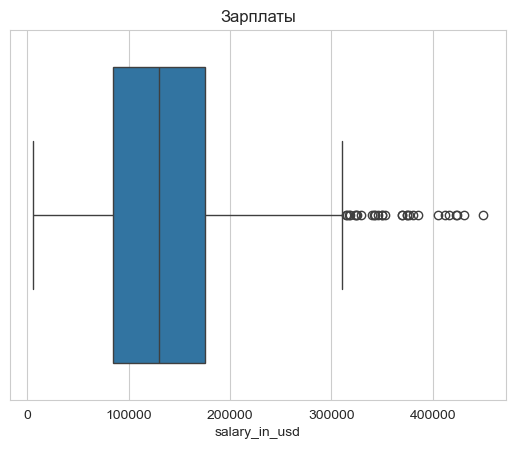

In [9]:
sns.boxplot(x=df['salary_in_usd'])
plt.title("Зарплаты")
plt.show()

In [10]:
#Да, выбросы есть, сейчас посмотрим кто это
high_salary = df[df['salary_in_usd'] > 300000][['job_title', 'salary_in_usd']].sort_values(by='salary_in_usd', ascending=False)
high_salary.head(15)

,job_title,salary_in_usd
3522,Research Scientist,450000
2011,Data Analyst,430967
528,AI Scientist,423834
3747,Applied Machine Learning Scientist,423000
3675,Principal Data Scientist,416000
3750,Data Scientist,412000
3463,Data Analytics Lead,405000
1288,Data Analyst,385000
3468,Applied Data Scientist,380000
649,Data Architect,376080


Да, выбросы в заработной плате есть, в топе это Research Scientist с зарплатой 45000 USD.

2. Влияет ли удаленная работа на зарплату? Есть ли корреляция?

In [11]:
out_local = df[['remote_ratio', 'salary_in_usd']].corr()
out_local.head(5)

,remote_ratio,salary_in_usd
remote_ratio,1.000000,-0.084502
salary_in_usd,-0.084502,1.000000


Итого, мы видим, что удаленная работа пусть и немного снижает заработную плату, но связь крайне мала (-0.085). Есть слабая обратная зависимость, но она настолько маленькая, что можно списать это на чистую случайность.

3. аЗависит ли заработная плата от размера предприятия?

In [12]:
df.groupby('company_size')['salary_in_usd'].mean()
#смотрим среднюю зп по размерам предприятий 

company_size
L    113202.239609
M    141474.514300
S     78364.278912
Name: salary_in_usd, dtype: float64

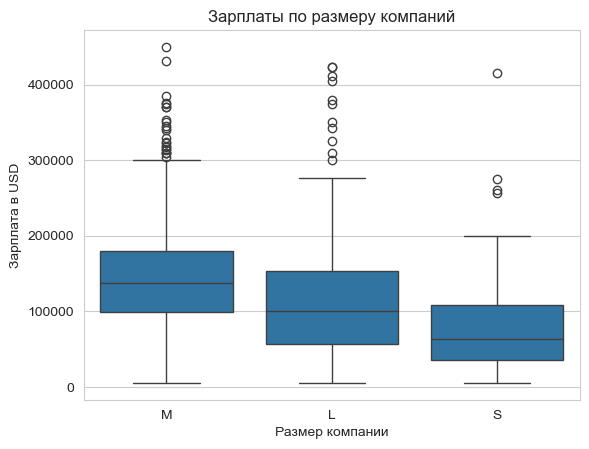

In [13]:
sns.boxplot(x='company_size', y='salary_in_usd', data=df)
plt.title('Зарплаты по размеру компаний')
plt.xlabel('Размер компании')
plt.ylabel('Зарплата в USD')
plt.show()

Ожидалось увидеть большое количество высоких зарплат в больших компаниях, но, как ни странно, больше лидирует средний размер компаний. Про маленькие компании всё в принципе ожидаемо, маленькая компания=маленький бюджет и заодно малое количество людей. Больше всего удивили средние компании. Их средняя зарплата в принципе даже больше чем зарплата в больших предприятиях, а так же большое количество людей с большой зарплатой. Прямого ответа влияет ли - дать нельзя, но с большей вероятностью размер предприятия НЕ влияет на размер зарплат.

4. Какие страны наиболее популярны среди вакансий? В каких заработная плата выше, а в каких ниже?

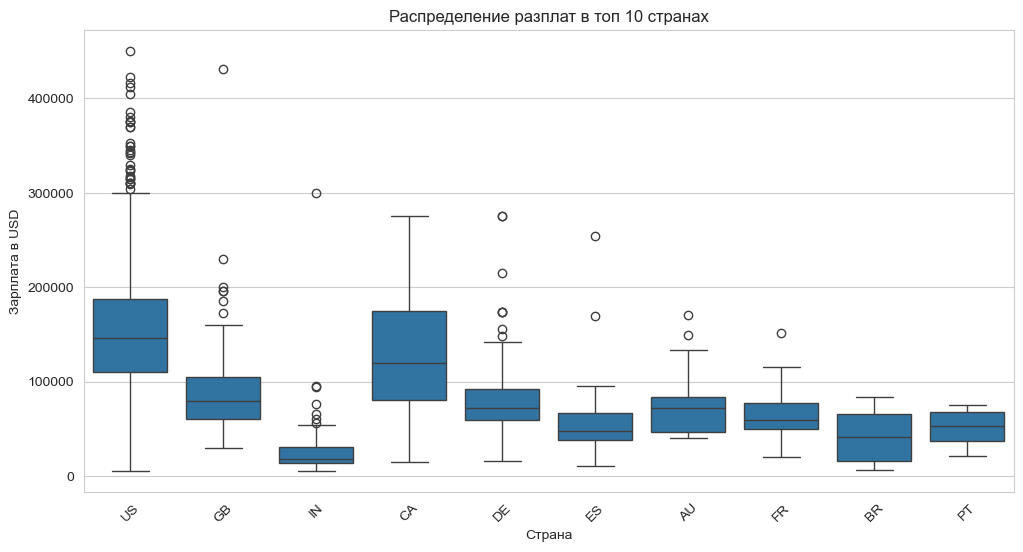

In [14]:
#визуализируем зарплаты по странам
top_countries = df['company_location'].value_counts().head(10).index
df_top = df[df['company_location'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.boxplot(x='company_location', y='salary_in_usd', data=df_top)
plt.title('Распределение разплат в топ 10 странах')
plt.xlabel('Страна')
plt.ylabel('Зарплата в USD')
plt.xticks(rotation=45)
plt.show()

In [15]:
top_country_per_job = (df.groupby('job_title')['company_location'].agg(lambda x: x.value_counts().idxmax()))
top_country_per_job.head(20)

job_title
3D Computer Vision Researcher         CR
AI Developer                          DE
AI Programmer                         AU
AI Scientist                          US
Analytics Engineer                    US
Applied Data Scientist                US
Applied Machine Learning Engineer     US
Applied Machine Learning Scientist    US
Applied Scientist                     US
Autonomous Vehicle Technician         BS
Azure Data Engineer                   NL
BI Analyst                            US
BI Data Analyst                       US
BI Data Engineer                      US
BI Developer                          US
Big Data Architect                    GB
Big Data Engineer                     GB
Business Data Analyst                 US
Business Intelligence Engineer        US
Cloud Data Architect                  US
Name: company_location, dtype: object

Самая высокая заработная плата в США и не удивительно что на большое количество профессий самой популярной страной является как раз таки США. Самая низкая заработная плата в Португалии и Бразилии, в том числе их выбирают меньше всего.

5. Оцените медианную зарплату для каждой должности.

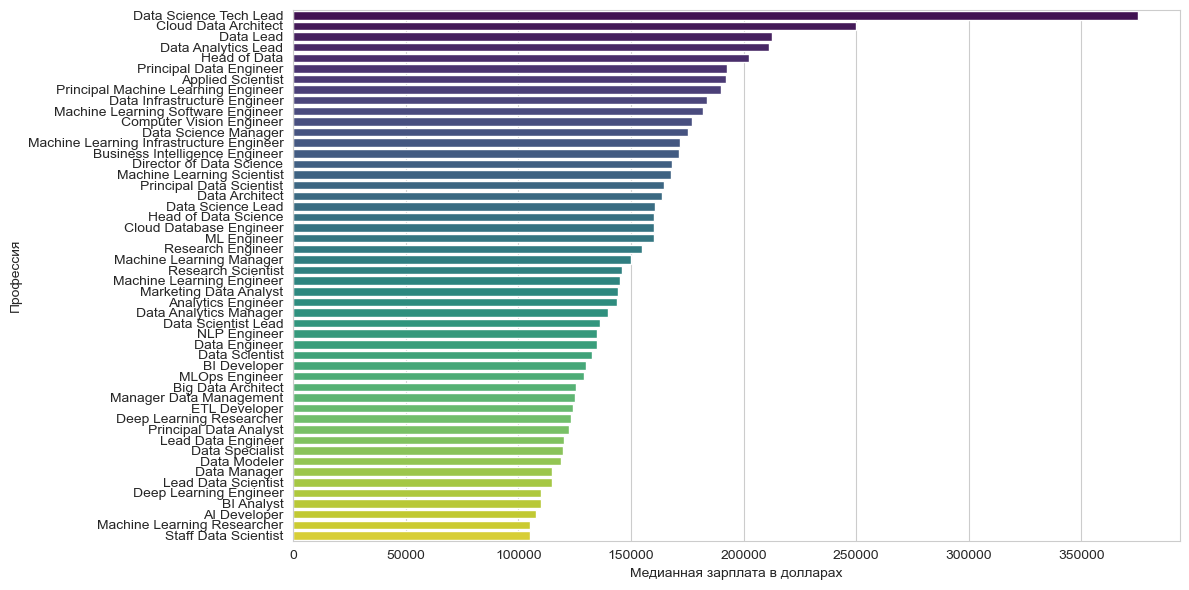

In [16]:
median_salary_per_job = (df.groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False).head(50))

plt.figure(figsize=(12,6,))
sns.barplot(x=median_salary_per_job.values, y=median_salary_per_job.index, palette='viridis')
plt.xlabel('Медианная зарплата в долларах')
plt.ylabel('Профессия')
plt.tight_layout()
plt.show()

На графике мы видим, что большинство профессий имеют сравнимые медианные зарплаты и лишь немногие выбиваются вверх, в основном зарплаты сосредоточены в средне-низких показателях. Однако есть небольшое количество высокооплачиваемых профессий, например data science tech lead, cloud data architecht. Они заметно выделяются среди других, формируя хвост в правой части. Я бы даже больше сказала, самая 'ненормально' оплачиваемая профессия это data science tech lead .

6. Оцените, как сильно изменились зарплаты в 2023 году, относительно 2020. Какие должности стали более оплачиваемы, а какие нет?

In [17]:
df_filtered = df[df['work_year'].isin([2020, 2023])]
median_by_year = (df_filtered.groupby(['job_title', 'work_year'])['salary_in_usd'].median().unstack().dropna())
median_by_year['change'] = median_by_year[2023] - median_by_year[2020]

In [18]:
#Топ профессий с ростом зп
median_by_year.sort_values(by='change', ascending=False).head(10)

work_year,2020,2023,change
job_title,,,
AI Scientist,45896.0,231232.5,185336.5
ML Engineer,15966.0,180000.0,164034.0
Computer Vision Engineer,60000.0,212500.0,152500.0
Machine Learning Infrastructure Engineer,50180.0,171600.0,121420.0
Data Scientist,62726.0,150000.0,87274.0
Data Analyst,34784.0,108000.0,73216.0
Data Engineer,72134.5,145000.0,72865.5
Data Science Consultant,54353.5,94000.0,39646.5
Machine Learning Engineer,144000.0,150450.0,6450.0


In [19]:
#Топ профессий с падением зп
median_by_year.sort_values(by='change').head(10)

work_year,2020,2023,change
job_title,,,
Research Scientist,246000.0,150900.0,-95100.0
Business Data Analyst,100000.0,21461.0,-78539.0
Director of Data Science,325000.0,249300.0,-75700.0
Principal Data Scientist,148261.0,85847.0,-62414.0
Machine Learning Scientist,260000.0,210000.0,-50000.0
Lead Data Analyst,87000.0,43119.0,-43881.0
BI Data Analyst,98000.0,71897.0,-26103.0
Big Data Engineer,109024.0,89144.5,-19879.5
Data Science Manager,190200.0,183382.5,-6817.5


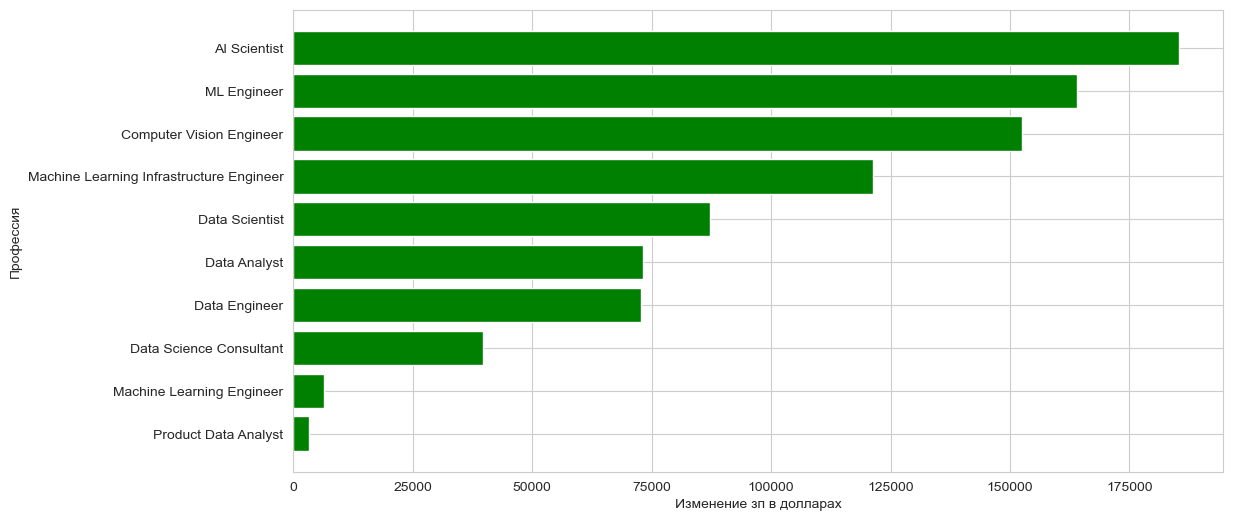

In [20]:
top_changes = median_by_year.sort_values(by='change', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_changes.index, top_changes['change'], color='green')
plt.xlabel('Изменение зп в долларах')
plt.ylabel('Профессия')
plt.gca().invert_yaxis()
plt.show()

Впериод с 2020 года по 2023 медианные зарплаты выросли, но не во многих профессиях, в основном зарплаты остались прежние или даже уменьшились. Можем наблюдать значительное повышение зарпллат в профессиях AI scientist, ML Engineer, Computer vision engineer, Machine learning infrastrucure engineer. В основном это связано с тем, что данные профессии сейчас бурно развиваются вместе с ИСкутвенным Интеллектом.

7. Выявите портрет самого успешного и богатого работника: кем он должен работать, где проживать, удаленная ли работа.

Технически, мы уже примерно можем знать, кто это будет. Какой-нибудь Data Science tech lead, проживающий в США и работающий очно. Но проверим так ли это.

In [22]:
top_person = df[df['salary_in_usd'] == df['salary_in_usd'].max()].iloc[0]
print(
    f"Самый успешный работник — это человек, работающий по профессии {top_person['job_title']}, "
    f"с зарплатой {top_person['salary_in_usd']}, проживающий в {top_person['company_location']}, "
    f"работающий {'удаленно' if top_person['remote_ratio'] == 100 else 'очно'} в {top_person['work_year']} году, "
    f"в компании размера {top_person['company_size']}"
)

Самый успешный работник — это человек, работающий по профессии Research Scientist, с зарплатой 450000, проживающий в US, работающий очно в 2020 году, в компании размера M


Ответ мы видим выше, я почти угадала, но к моему удивлению успешный человек это совсем не Data science tech lead, но проживающий в США и работющий очно.

8. Много ли людей работают и проживают в разных регионах? Где больше всего людей проживает и много ли из них (в процентном соотношении) работают удаленно на другую страну?

In [29]:
df['foreign_work'] = df['employee_residence'] != df['company_location']

foreign_count = df['foreign_work'].sum()
total_count = len(df)
percent_foreign = round((foreign_count / total_count) * 100, 2)

print(f'Людей, работающих на другую страну: {foreign_count} из {total_count} ({percent_foreign}%)')

Людей, работающих на другую страну: 96 из 2584 (3.72%)


In [36]:
residence_counts = df['employee_residence'].value_counts()
remote_ratio_per_country = (df.groupby('employee_residence')['remote_ratio'].apply(lambda x: (x == 100).mean() * 100).sort_values(ascending=False))
summary = pd.DataFrame({'num_residents': residence_counts, 'percent_remote': remote_ratio_per_country}).dropna().sort_values(by='num_residents', ascending=False)

In [37]:
summary.head(10)

,num_residents,percent_remote
employee_residence,,
US,1893,46.909667
GB,150,34.000000
CA,81,53.086420
IN,70,54.285714
ES,47,48.936170
DE,47,36.170213
FR,37,37.837838
PT,18,44.444444
BR,18,88.888889


По данным мы видим, что огромное количество людей работают в странах, где проживают (или как минимум потом туда переезжают, но такой информации у нас точно нет) и только почти 4% работает удаленно в другой стране. 

Так же мы видим, что большее количество людей проживает в США, НО здесь так же и практически 50% удаленной работы.

9. Выявите новые инсайты, если захотите! Творите! 

Мне стало интересно, сильно ли влияет опыт работы на зарплату по отношению к каждой профессии.

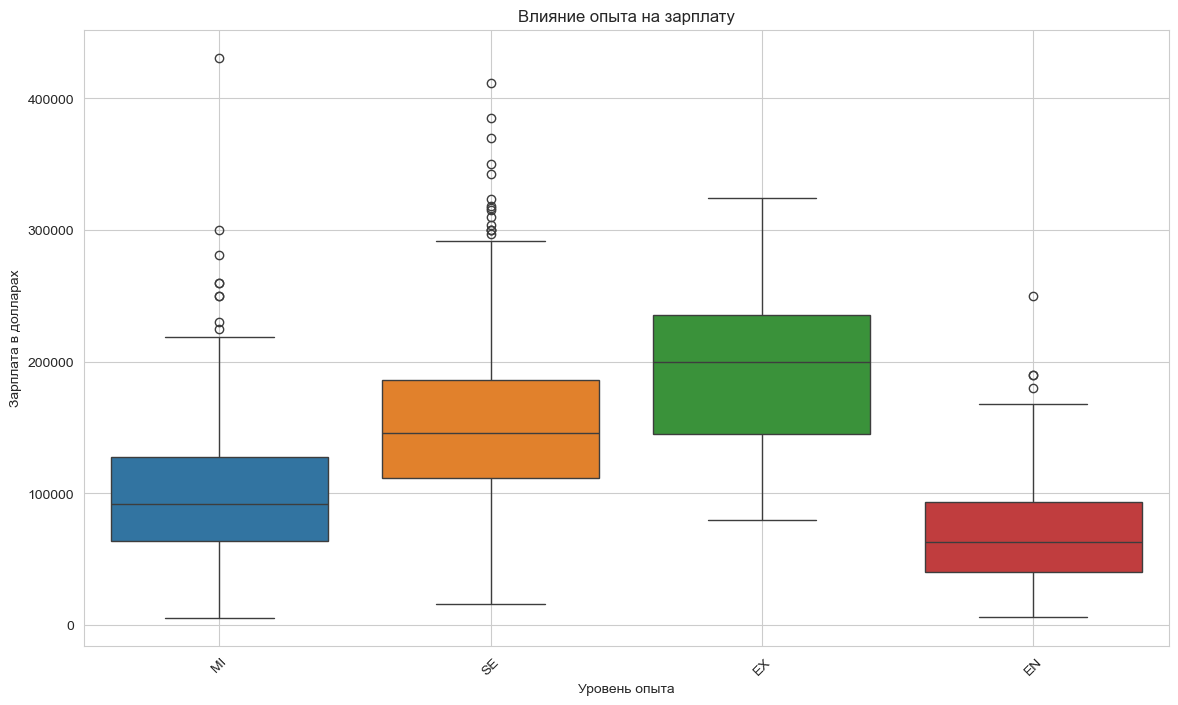

In [44]:
top_jobs = df['job_title'].value_counts().head(5).index
filtered_df = df[df['job_title'].isin(top_jobs)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=filtered_df,
    x='experience_level',
    y='salary_in_usd',
    hue='experience_level',
    dodge=False)
plt.title('Влияние опыта на зарплату')
plt.xlabel('Уровень опыта')
plt.ylabel('Зарплата в долларах')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Мы видим, что в основном Руководящие должности (СЕО) чаще всего получают стабильную зарплату, но достаточно большую, однако буквально уровнем ниже сеньор получает стабильно МЕНЬШЕ зп, но чаще всего у них происходят выбросы в высокие заработные платы, даже выше чем у СЕО. Джуны, разумеется, получают меньше всех, но иногда вырываются вперед минимум на уровень сеньора. Миддл специалисты получше новичков, у них достаточно хорошая стабильная ЗП и чаще вырываются вверх.